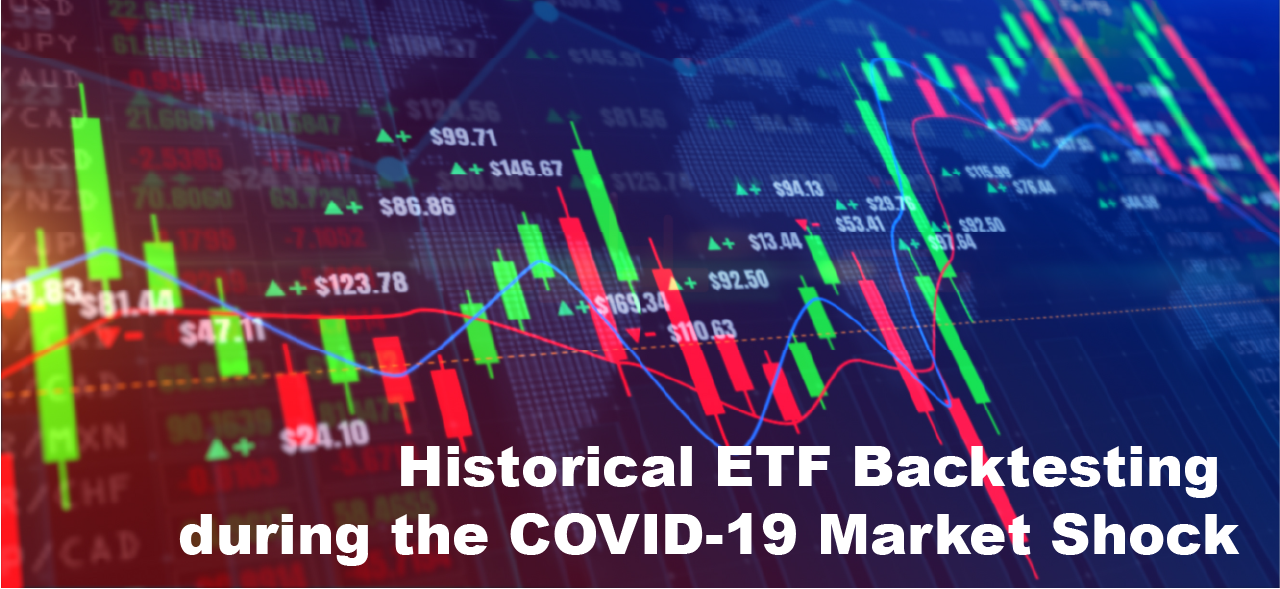

In [1]:
# @title
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/DATASCI 200

Mounted at /content/drive
/content/drive/MyDrive/DATASCI 200


##2.2. Project Questions

To guide the analysis, this project examines the following core questions:

  1.   How did strategy outcomes differ across market segments?
  2.   Which strategies remained resilient during periods of market stress?
  3.   Which strategies were most sensitive to the recovery phase and shifts in market conditions?

#3. Data Preparation & Cleaning

##3.1. Loading the Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime
import numpy as np
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [3]:
ticker_paths = {
    "SPY": "S&P/SPY.csv",
    "XLE": "S&P/XLE.csv",
    "XLF": "S&P/XLF.csv",
    "XLI": "S&P/XLI.csv",
    "XLP": "S&P/XLP.csv",
    "XLV": "S&P/XLV.csv",
}

In [4]:
# First look at the dataset, using the 'SPY.csv' as an example.
example = pd.read_csv(ticker_paths['SPY'])
example.head()

,Date,Open,High,Low,Close,Volume
0,1993-01-29,24.330332,24.330332,24.209286,24.313040,1003200
1,1993-02-01,24.330325,24.485956,24.330325,24.485956,480500
2,1993-02-02,24.468672,24.555134,24.416795,24.537842,201300
3,1993-02-03,24.572429,24.814522,24.555137,24.797230,529400
4,1993-02-04,24.883684,24.952853,24.607006,24.900976,531500


In [5]:
example.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8263 entries, 0 to 8262
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    8263 non-null   object 
 1   Open    8263 non-null   float64
 2   High    8263 non-null   float64
 3   Low     8263 non-null   float64
 4   Close   8263 non-null   float64
 5   Volume  8263 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 387.5+ KB


## 3.2. Feature Engineering

In [6]:
def features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generates the core feature sets used to analyze our strategies,
    including moving averages, returns, volatility measures, volume trends,
    and price-based indicators.
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    # Simple Moving Averages
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['SMA_50'] = df['Close'].rolling(50).mean()
    df['SMA_200'] = df['Close'].rolling(200).mean()

    # Returns
    df['daily_ret'] = df['Close'].pct_change()
    df['five_day_ret'] = df['Close'].pct_change(5)

    # Volatility
    df['vol_20'] = df['daily_ret'].rolling(20).std()
    df['vol_60'] = df['daily_ret'].rolling(60).std()
    df['vol_ratio'] = df['vol_20'] / df['vol_60']

    # Volume
    df['vol_ma20'] = df['Volume'].rolling(20).mean()

    # Intraday Range
    df['IDR'] = (df['High'] - df['Low']) / df['Close']

    # Gap
    prev_close = df['Close'].shift(1)
    df['Gap'] = (df['Open'] - prev_close)/prev_close

    return df

##3.3. Generating Cleaned Dataframes

In [7]:
def file_to_df(csv_file: str, start_date: str, end_date: str) -> pd.DataFrame:
  """
  Load and preprocess historical price data from a CSV file, clean and format the
  columns, apply the features() function, and return the date-filtered DataFrame.
  """
  csv = pd.read_csv(csv_file)
  csv = csv.iloc[1:].reset_index(drop=True)
  csv['Date'] = pd.to_datetime(csv['Date'])
  num_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
  csv[num_cols] = csv[num_cols].apply(pd.to_numeric)
  csv = csv.set_index('Date').sort_index()
  csv_covid = features(csv).loc[start_date:end_date].copy()
  return csv_covid

In [8]:
def load_period_data(ticker_paths: dict, start_date: str, end_date: str) -> dict:
    """
    For each ticker, this function applies the file-to-dataframe pipeline and returns a
    dictionary mapping tickers to their cleaned dataframes.
    """
    data = {}
    for ticker, path in ticker_paths.items():
        data[ticker] = file_to_df(path, start_date, end_date)
    return data

##3.4. Market Period Definitions

Before moving into the analysis, we defined the time periods and market segments used throughout the project and stored them in dictionaries for easy reference in our code.

1.   **CRISES** is a dictionary of our comparison time periods
2.   **KEY_EVENTS** is a dictionary of key market events we wanted to annotate in our time series.
3.   **MARKETS** is a dictionary of S&P tickers and the sectors they represent.


In [9]:
CRISES = {
    "COVID_FULL": {
        "start": "2020-01-30",
        "end": "2021-12-31"
    },
    "COVID_CRASH": {
        "start": "2020-02-20",
        "end": "2020-03-23"
    },
    "COVID_RECOVERY": {
        "start": "2020-03-24",
        "end": "2020-11-24"
    }
}

In [10]:
KEY_EVENTS = {
    1: ("Market Selloff Begins", "2020-02-24", "crash"),
    2: ("Market hits its bottom for the year", "2020-03-23", "crash"),
    3: ("First States Begin Limited Reopening", "2020-04-24", "recovery"),
    4: ("Pfizer Vaccine Announcement", "2020-11-09", "recovery"),
    5: ("The American Rescue Plan, a $1.9T stimulus package is signed into law", "2021-03-11", "recovery"),
    6: ("First U.S. Mass Vaccination Rollout", "2021-04-19", "recovery"),
    7: ("Increasing volatility driven by rising inflation and concerns over the Omicron variant", "2021-11-26", "recovery"),
}

In [11]:
MARKETS = {
    "SPY": "Broad Market (S&P 500)",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLP": "Consumer Staples",
    "XLV": "Healthcare"
}

In [12]:
# Example of cleaned dataframe for the COVID_FINANCIAL PERIOD.
start = pd.to_datetime(CRISES["COVID_FULL"]["start"])
end   = pd.to_datetime(CRISES["COVID_FULL"]["end"])

# Width for pretty section headers in the console
win_size = shutil.get_terminal_size().columns // 2

# Load preprocessed data for all tickers over this period
covid_data = load_period_data(ticker_paths, start, end)

# Inspect dtypes and sample rows for each ticker
for ticker, df in covid_data.items():
    print("\n" + "=" * win_size + f" {ticker} " + "=" * win_size)
    print(df.dtypes)
    display(df.head(3))


======================================== SPY ========================================
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
SMA_20          float64
SMA_50          float64
SMA_200         float64
daily_ret       float64
five_day_ret    float64
vol_20          float64
vol_60          float64
vol_ratio       float64
vol_ma20        float64
IDR             float64
Gap             float64
dtype: object


,Open,High,Low,Close,Volume,SMA_20,SMA_50,SMA_200,daily_ret,five_day_ret,vol_20,vol_60,vol_ratio,vol_ma20,IDR,Gap
Date,,,,,,,,,,,,,,,,
2020-01-30,298.109962,301.372682,297.356345,301.161285,75491800,300.754094,293.916476,274.235099,0.003246,-0.012179,0.006605,0.004976,1.327486,63907910.0,0.013336,-0.006919
2020-01-31,300.536306,300.692560,294.773739,295.692810,113845600,300.609804,294.123021,274.399190,-0.018158,-0.021413,0.007553,0.005555,1.359659,66642630.0,0.020017,-0.002075
2020-02-03,297.181729,299.764318,297.062246,297.889404,69083000,300.688388,294.375144,274.577480,0.007429,0.001917,0.007554,0.005613,1.345866,66211295.0,0.009071,0.005035



======================================== XLE ========================================
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
SMA_20          float64
SMA_50          float64
SMA_200         float64
daily_ret       float64
five_day_ret    float64
vol_20          float64
vol_60          float64
vol_ratio       float64
vol_ma20        float64
IDR             float64
Gap             float64
dtype: object


,Open,High,Low,Close,Volume,SMA_20,SMA_50,SMA_200,daily_ret,five_day_ret,vol_20,vol_60,vol_ratio,vol_ma20,IDR,Gap
Date,,,,,,,,,,,,,,,,
2020-01-30,42.385177,43.222705,42.275591,43.175739,24430500,45.774811,45.558306,45.535856,0.008041,-0.037011,0.009702,0.010596,0.915609,15792445.0,0.021936,-0.010417
2020-01-31,42.447792,42.565204,41.610264,41.829430,33430500,45.495374,45.501482,45.495189,-0.031182,-0.056164,0.010913,0.010420,1.047320,16866735.0,0.022829,-0.016860
2020-02-03,41.774639,41.837259,41.132795,41.281517,21289200,45.195586,45.446946,45.452114,-0.013099,-0.041962,0.010991,0.010519,1.044867,16456050.0,0.017065,-0.001310



======================================== XLF ========================================
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
SMA_20          float64
SMA_50          float64
SMA_200         float64
daily_ret       float64
five_day_ret    float64
vol_20          float64
vol_60          float64
vol_ratio       float64
vol_ma20        float64
IDR             float64
Gap             float64
dtype: object


...

,Open,High,Low,Close,Volume,SMA_20,SMA_50,SMA_200,daily_ret,five_day_ret,vol_20,vol_60,vol_ratio,vol_ma20,IDR,Gap
Date,,,,,,,,,,,,,,,,
2020-01-30,74.827266,75.720022,74.672403,75.638031,13158200,75.803381,74.676277,70.630927,0.001085,-0.010841,0.008308,0.006609,1.256980,11881425.0,0.013850,-0.009646
2020-01-31,75.228084,75.337397,73.606555,73.888954,19083600,75.716837,74.667451,70.653289,-0.023124,-0.029204,0.008835,0.007136,1.237999,12029540.0,0.023425,-0.005420
2020-02-03,74.289830,74.909291,73.779680,73.861671,15676600,75.636217,74.659349,70.675065,-0.000369,-0.010857,0.008834,0.007132,1.238707,11934805.0,0.015294,0.005425



======================================== XLP ========================================
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
SMA_20          float64
SMA_50          float64
SMA_200         float64
daily_ret       float64
five_day_ret    float64
vol_20          float64
vol_60          float64
vol_ratio       float64
vol_ma20        float64
IDR             float64
Gap             float64
dtype: object


,Open,High,Low,Close,Volume,SMA_20,SMA_50,SMA_200,daily_ret,five_day_ret,vol_20,vol_60,vol_ratio,vol_ma20,IDR,Gap
Date,,,,,,,,,,,,,,,,
2020-01-30,54.317523,54.979513,54.283133,54.936527,13824800,54.330849,53.730986,51.180850,0.011876,-0.002030,0.005254,0.004304,1.220818,12093885.0,0.012676,0.000475
2020-01-31,54.962323,55.203045,54.162777,54.317528,15280000,54.360940,53.765906,51.214598,-0.011268,-0.006448,0.005586,0.004376,1.276622,12134850.0,0.019152,0.000470
2020-02-03,54.515264,54.721600,54.274542,54.317528,21797600,54.395329,53.802191,51.247169,0.000000,-0.003313,0.005565,0.004365,1.274829,11905285.0,0.008230,0.003640



======================================== XLV ========================================
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
SMA_20          float64
SMA_50          float64
SMA_200         float64
daily_ret       float64
five_day_ret    float64
vol_20          float64
vol_60          float64
vol_ratio       float64
vol_ma20        float64
IDR             float64
Gap             float64
dtype: object


,Open,High,Low,Close,Volume,SMA_20,SMA_50,SMA_200,daily_ret,five_day_ret,vol_20,vol_60,vol_ratio,vol_ma20,IDR,Gap
Date,,,,,,,,,,,,,,,,
2020-01-30,92.187105,92.250902,91.403309,92.196220,10989400,93.697721,91.887658,84.227195,-0.007262,-0.029174,0.006424,0.005996,1.071444,8151910.0,0.009193,-0.007360
2020-01-31,91.831656,91.904562,90.054441,90.355202,14476700,93.561469,91.943000,84.284085,-0.019968,-0.032403,0.007731,0.006572,1.176296,8561875.0,0.020476,-0.003954
2020-02-03,90.984062,91.831655,90.984062,91.175453,11850600,93.506786,92.002843,84.356432,0.009078,-0.016129,0.007874,0.006567,1.199006,8742030.0,0.009296,0.006960


##3.5. Strategy Functions

###3.5.1. Buy-and-Hold

In [13]:
def buy_and_hold(df: pd.DataFrame) -> pd.Series:
    """
    Generate a signal by returning a boolean Series of all True values
    across the full index of the input dataframe, indicating a fully invested
    position for the entire period.
    """

    return pd.Series(True, index=df.index)

###3.5.2. Simple Moving Average (50-Day)

In [14]:
def sma50(df: pd.DataFrame) -> pd.Series:
    """
    Generate a simple trend-following signal based on the 50-day SMA.
    Returns True when the closing price is above the 50-day moving average
    and False otherwise.
    """

    signal = df['Close'] > df['SMA_50']
    return signal

###3.5.3. Buy-the-Dip

In [15]:
def buy_the_dip(df: pd.DataFrame, dip: float = -0.05) -> pd.Series:
    """
    Generate a buy signal when the 5-day return exceeds the -5.0% threshold.
    """

    signal = df['five_day_ret'] > dip
    return signal

###3.5.4. Multi-Factor Technical Strategy (Weighted Composite Score)

In [16]:
def mf_signals(df: pd.DataFrame) -> pd.Series:
    """
    Generate a composite multi-factor trading signal using RSI, MACD, trend, and
    volatility indicators. Each metric is normalized into a score, combined with
    predefined weights, and converted into a final long/flat/short position signal.
    """

    w_rsi=0.3
    w_macd=0.3
    w_trend=0.3
    w_vol=0.1
    threshold=0.05

    data = df.copy()

    # ===== RSI =====
    delta = data['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    data['RSI'] = 100 - (100 / (1 + rs))
    data['RSI_score'] = (50 - data['RSI']) / 50   # normalized to -1..+1

    # ===== MACD =====
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    data['MACD_hist'] = macd - signal

    # Safer normalization (no division by tiny std)
    macd_den = data['MACD_hist'].abs().rolling(50).mean()
    data['MACD_score'] = (data['MACD_hist'] / macd_den).clip(-1, 1)

    # ===== Trend Score (price above 50 SMA) =====
    data['SMA50'] = data['Close'].rolling(50).mean()
    data['Trend_score'] = np.where(data['Close'] > data['SMA50'], 1, -1)

    # ===== Volatility Score (low vol = bullish) =====
    vol20 = data['Close'].pct_change().rolling(20).std()
    vol200 = data['Close'].pct_change().rolling(200).mean().abs()
    data['Vol_score'] = (1 - (vol20 / vol200)).clip(-1, 1)


    # ===== Fill NaNs safely =====
    data[['RSI_score','MACD_score','Trend_score','Vol_score']] = \
        data[['RSI_score','MACD_score','Trend_score','Vol_score']].fillna(0)

    # ===== Composite Score =====
    data['Score'] = (
        w_rsi * data['RSI_score'] +
        w_macd * data['MACD_score'] +
        w_trend * data['Trend_score'] +
        w_vol * data['Vol_score']
    )

    # ===== Trading Signal =====
    data['Position'] = 0
    data.loc[data['Score'] > threshold, 'Position'] = 1
    data.loc[data['Score'] < -threshold, 'Position'] = -1

    data['Position'] = data['Position'].replace(0, np.nan).ffill().fillna(0)

    return data['Position']

###3.5.5. Regime Strategy

In [17]:
def regime_strategy(
    df,
    panic_ret=-0.04,
    panic_range=0.05,
    panic_vol_spike=1.5,
    gap_panic_threshold=-0.03
) -> pd.Series:
    """
    The strategy usesprice trend, volatility structure, volume strength,
    intraday range, and opening gap behavior to determine whether the market is
    in a favorable regime for holding a long position.
    """

    df = df.copy()
    # Uptrend vs Downtrend
    uptrend = df['Close'] > df['SMA_20']
    normal_volatility = df['vol_20'] < df['vol_60']
    normal_volume = df['Volume'] >= df['vol_ma20'] * 0.8

    panic_day = (
        (df['daily_ret'] <= panic_ret) &
        (df['IDR'] >= panic_range) &
        (df['Volume'] >= panic_vol_spike * df['vol_ma20'])
    )

    gap_panic = df['Gap'] <= gap_panic_threshold

    panic = panic_day | gap_panic

    signal = uptrend & normal_volatility & normal_volume & (~panic)

    return signal

###3.5.6. SMA Crossover Strategy

In [18]:
def smaC_strategy(df: pd.DataFrame) -> pd.Series:
    """
    Generate a trading signal based on a SMA crossover, returning True when
    the 50-day SMA is above the 200-day SMA.
    """

    df = df.copy()
    signal = df['SMA_50'] > df['SMA_200']
    return signal

##3.6. Strategies and Time Periods Summary

In [19]:
STRATEGIES = {
    1: ("Buy & Hold", buy_and_hold),
    2: ("50-Day SMA", sma50),
    3: ("Buy-the-Dip", buy_the_dip),
    4: ("Multi-Factor Technical", mf_signals),
    5: ("Regime Strategy", regime_strategy),
    6: ("SMA Crossover", smaC_strategy)
}

We also define the specific time periods used in our analysis as variables to make them easy to reference throughout the code:

In [20]:
PERIOD_START = pd.to_datetime(CRISES["COVID_FULL"]["start"])
PERIOD_END = pd.to_datetime(CRISES["COVID_FULL"]["end"])
CRASH_START = pd.to_datetime(CRISES["COVID_CRASH"]["start"])
CRASH_END = pd.to_datetime(CRISES["COVID_CRASH"]["end"])
RECOVERY_START = pd.to_datetime(CRISES["COVID_RECOVERY"]["start"])
RECOVERY_END = pd.to_datetime(CRISES["COVID_RECOVERY"]["end"])

#4. Analytical Framework and Supporting Functions

##4.1. Backtester Class

In [21]:
class Backtester:
    """
    A backtesting engine that applies trading signals to historical price data
    and computes the resulting portfolio performance over time.
    """

    def __init__(self, df: pd.DataFrame, initial_capital: float):
        """
        Initialize the Backtester with a price dataframe and starting capital.
        """

        self.df = df.copy()
        self.initial_capital = initial_capital

    def run(self, signals: pd.Series) -> pd.DataFrame:
        """
        Apply a strategy's trading signals to the price data and compute the
        resulting portfolio path.
        """

        df = self.df.copy()

        df['Signal'] = signals

        # Convert True/False to 1 or 0
        df['Position'] = signals.astype(int)

        # Calculate daily returns
        df['Return'] = df['Close'].pct_change()

        # Daily returns
        df['Return'] = df['Close'].pct_change()

        # Strategy return = asset return * position
        df['Strategy_Return'] = df['Return'] * df['Position']

        # Portfolio value over time
        df['Portfolio'] = (1 + df['Strategy_Return']).cumprod() * self.initial_capital

        # Ensure the first value is the starting capital
        df.loc[df.index[0], 'Portfolio'] = self.initial_capital

        return df

    def summary(self, result_df: pd.DataFrame):
        """
        Print a simple performance summary of the strategy, including
        initial capital, final portfolio value, and total return.
        """

        initial = self.initial_capital
        final = result_df['Portfolio'].iloc[-1]
        total_return = (final / initial - 1) * 100

        print(f"Initial Capital: ${initial:,.2f}")
        print(f"Final Portfolio Value: ${final:,.2f}")
        print(f"Total Return: {total_return:.2f}%")

##4.2. Applying Strategy Functions

###4.2.1. Apply a strategy to a single ticker

In [22]:
def apply_strategy(backtester, signals) -> pd.DataFrame:
  """
  Run a strategy by passing its signal series into a Backtester instance and
  returning the resulting performance DataFrame.
  """

  strat_result = backtester.run(signals)
  return strat_result

###4.2.2. Apply a strategy to a group of tickers for a period range

In [23]:
def apply_strategy_to_period(strat_func, start_date, end_date, initial_capital: float) -> dict:
    """
    Apply a single strategy function across all tickers for the selected date range.
    This function loads and preprocesses price data for each ticker, generates strategy
    signals using the provided strategy function, runs the Backtester for each market,
    and returns a dictionary mapping tickers to their resulting strategy dataframes.
    """

    data = {}
    tickers = ticker_paths
    for ticker, path in ticker_paths.items():
        data[ticker] = file_to_df(path, start_date, end_date)

    results = {}
    for ticker, df in data.items():
      bt = Backtester(df, initial_capital)
      signals = strat_func(df)
      results[ticker] = apply_strategy(bt, signals)
    return results

###4.2.3. Calculating the returns of each strategy across market sectors

In [24]:
def all_returns(results_dict, initial_capital):
    """
    Compute total returns for each strategy across all tickers. This function takes a
    dictionary of strategy dataframe results, extracts the final portfolio value
    for each ticker, converts it into a percentage return relative to the
    initial capital, maps each ticker to its corresponding market sector, and
    returns a dataframe summarizing strategy performance by sector.
    """

    data = {}

    for _, (strat_name, strat_results) in results_dict.items():
        row = {}

        for ticker, strat_df_result in strat_results.items():
            final = strat_df_result["Portfolio"].iloc[-1]
            total_return = (final / initial_capital - 1) * 100

            sector_name = MARKETS[ticker]
            row[sector_name] = total_return

        data[strat_name] = row

    return pd.DataFrame.from_dict(data, orient="index")

###4.2.4. Calculating the returns of each strategy across market sectors by date range

In [25]:
def returns_for_period(start_date, end_date, initial_capital) -> pd.DataFrame:
    """
    Run all strategies over the specified date range and compute their total returns.
    This function applies each strategy to all selected market tickers, aggregates
    the per-ticker results, and returns a summarized DataFrame of strategy-level returns.
    """

    all_strats = {}

    # strategies: {1: ("Buy & Hold", buy_and_hold), 2: (...), ...}
    for i, (strat_name, strat_func) in STRATEGIES.items():
        strat_results = apply_strategy_to_period(
            strat_func,
            start_date,
            end_date,
            initial_capital
        )
        # strat_results is {ticker: strat_df_result}
        all_strats[i] = (strat_name, strat_results)

    return all_returns(all_strats, initial_capital)

##4.3. Performance Reporting and Visualization

###4.3.1. Printing a summary of performance results

In [26]:
def print_results(market_dictionary, results_dictionary, strategy_name) -> None:
    """
    Print the performance results for a given strategy across all selected markets.
    This function displays each market's initial capital, final portfolio value, and
    total percentage return.
    """

    print(f"\n----- {strategy_name} -----")

    for ticker, sector in market_dictionary.items():

        # Unpack: Backtester, result DataFrame
        strat_result = results_dictionary[ticker]

        initial_capital = strat_result["Portfolio"].iloc[0]
        final_value = strat_result["Portfolio"].iloc[-1]
        total_return = (final_value / initial_capital - 1) * 100

        print(f"\n----- {ticker} ({sector}) -----")
        print(f"Initial Capital: ${initial_capital:,.2f}")
        print(f"Final Portfolio Value: ${final_value:,.2f}")
        print(f"Total Return: {total_return:.2f}%")

###4.3.2. Displaying a time series chart

In [27]:
def print_time_series(strat_results: dict, strategy_name: str, ax=None) -> None:
    """
    Plot the time-series performance of a strategy across all sectors and annotate
    key market events. If `ax` is provided, plot into that axis; otherwise create
    a new figure and axis.
    """

    tickers = list(strat_results.keys())

    colormap = plt.cm.tab10
    colors = [colormap(i) for i in np.linspace(0, 0.9, len(tickers))]
    colordict = dict(zip(tickers, colors))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(16, 6))
        created_fig = True

    for ticker in tickers:
        strat_df_result = strat_results[ticker]
        sector_name = MARKETS[ticker]
        ax.plot(
            strat_df_result["Portfolio"],
            label=sector_name,
            color=colordict[ticker]
        )

    all_dates = pd.concat(
        [df["Portfolio"] for df in strat_results.values()]
    ).index

    start_date = all_dates.min()
    end_date = all_dates.max()

    ax.tick_params(axis="x", rotation=30)
    ax.set_title(f"{strategy_name} Strategy Across Sectors During COVID", fontsize=12)
    ax.legend(title="Sector", ncol=2, labelspacing=.1, fontsize=8, title_fontsize=9)
    ax.grid(True)

    ymin, ymax = ax.get_ylim()
    y_pos = ymin + (ymax - ymin) * 0.9

    for num, event_tuple in KEY_EVENTS.items():
        label, date_str, _ = event_tuple
        event_dt = pd.to_datetime(date_str)

        # Skip events outside plotted range
        if not (start_date <= event_dt <= end_date):
            continue

        # Event markers
        ax.axvline(event_dt, color='gray', linestyle='--', alpha=0.6)

        ax.text(
            event_dt,
            y_pos,
            str(num),
            fontsize=10,
            fontweight='bold',
            ha='center',
            va='center',
            color='white',
            bbox=dict(
                boxstyle="circle,pad=0.3",
                fc="black",
                ec="none",
                alpha=0.8
            )
        )

    # Labels and formatting
    ax.set_ylabel("Portfolio Value ($)")
    fmt = "${x:,.0f}"
    tick = mtick.StrMethodFormatter(fmt)
    ax.yaxis.set_major_formatter(tick)
    ax.set_xlabel("Date")

    if created_fig:
        plt.show()

        print("\n" + "="*20 + " MARKET TIMELINE " + "="*20)
        for index, event_tuple in KEY_EVENTS.items():
            label, date_str, _ = event_tuple
            event_dt = pd.to_datetime(date_str)

            if not (start_date <= event_dt <= end_date):
                continue

            full_date = event_dt.strftime("%B %d, 2020")
            print(f"\033[1m{index}. {full_date}:\033[0m {label}")


###4.3.3. Displaying a heatmap of returns

In [28]:
def print_heatmap(strat_results: dict, start_date: datetime, end_date: datetime) -> None:
    """
    Generate a heatmap showing sector-level returns for a given strategy.
    The function formats the results as percentages, applies a custom
    red-to-green colormap centered at zero, and visualizes how each sector
    performed under the selected strategy.
    """

    returns_df = strat_results.T

    colors = [
        "#8B0000",
        "#FF4040",
        "#FFFFFF",
        "#32CD32",
        "#006400"
    ]

    color_map = LinearSegmentedColormap.from_list("custom_red_green", colors, N=256)

    annot = returns_df.map(lambda x: f"{x:.1f}%")

    plt.figure(figsize=(16, 6))
    heat_1 = sns.heatmap(
        returns_df,
        annot=annot,
        fmt="",
        cmap=color_map,
        center=0,
        linewidths=0.5,
    )

    heat_1.set_xticklabels(heat_1.get_xticklabels(), rotation=45, ha='right')
    heat_1.set_yticklabels(heat_1.get_yticklabels(), rotation=0)

    start_date = start_date
    end_date = end_date

    plt.title(f"Market Heatmap {start_date.strftime('%b %Y')} - {end_date.strftime('%b %Y')} (%)", fontsize=18)
    plt.xlabel("Strategy", fontsize=14)
    plt.ylabel("Sector", fontsize=14)
    plt.tight_layout()
    # plt.show()


#5. Strategy Performance Across Market Segments

##5.1. Buy-and-Hold Analysis

In [29]:
bh_full_results = apply_strategy_to_period(buy_and_hold, PERIOD_START, PERIOD_END, 100000)

In [30]:
print_results(MARKETS, bh_full_results, "Buy & Hold")


----- Buy & Hold -----

----- SPY (Broad Market (S&P 500)) -----
Initial Capital: $100,000.00
Final Portfolio Value: $149,621.29
Total Return: 49.62%

----- XLE (Energy) -----
Initial Capital: $100,000.00
Final Portfolio Value: $112,331.49
Total Return: 12.33%

----- XLF (Financials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $133,236.44
Total Return: 33.24%

----- XLI (Industrials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $131,762.99
Total Return: 31.76%

----- XLP (Consumer Staples) -----
Initial Capital: $100,000.00
Final Portfolio Value: $127,197.81
Total Return: 27.20%

----- XLV (Healthcare) -----
Initial Capital: $100,000.00
Final Portfolio Value: $143,783.79
Total Return: 43.78%


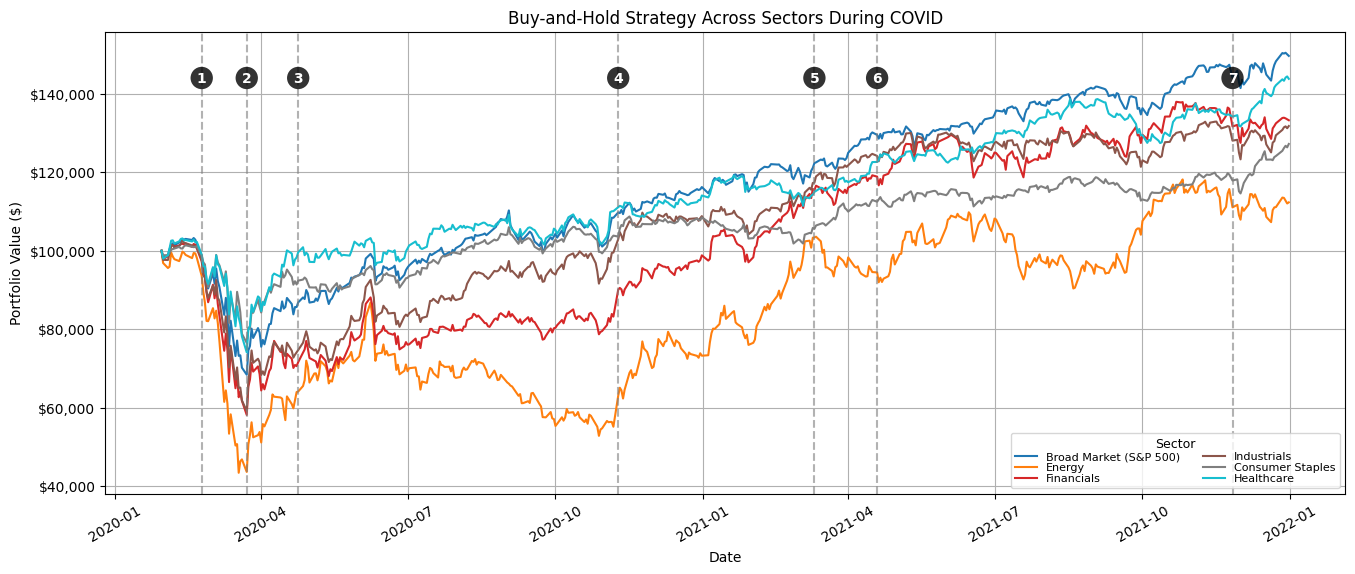


==================== MARKET TIMELINE ====================
1. February 24, 2020: Market Selloff Begins
2. March 23, 2020: Market hits its bottom for the year
3. April 24, 2020: First States Begin Limited Reopening
4. November 09, 2020: Pfizer Vaccine Announcement
5. March 11, 2020: The American Rescue Plan, a $1.9T stimulus package is signed into law
6. April 19, 2020: First U.S. Mass Vaccination Rollout
7. November 26, 2020: Increasing volatility driven by rising inflation and concerns over the Omicron variant


In [31]:
print_time_series(bh_full_results, "Buy-and-Hold")

##5.2. Simple Moving Average


Rules:

*  Buy when price is above 50-day SMA
*  Sell when price is below 50-day SMA

In [32]:
sma50_full_results = apply_strategy_to_period(sma50, PERIOD_START, PERIOD_END, initial_capital=100000)

In [33]:
print_results(MARKETS, sma50_full_results, "50-Day SMA")


----- 50-Day SMA -----

----- SPY (Broad Market (S&P 500)) -----
Initial Capital: $100,000.00
Final Portfolio Value: $216,042.72
Total Return: 116.04%

----- XLE (Energy) -----
Initial Capital: $100,000.00
Final Portfolio Value: $310,474.60
Total Return: 210.47%

----- XLF (Financials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $276,941.69
Total Return: 176.94%

----- XLI (Industrials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $222,130.68
Total Return: 122.13%

----- XLP (Consumer Staples) -----
Initial Capital: $100,000.00
Final Portfolio Value: $183,676.97
Total Return: 83.68%

----- XLV (Healthcare) -----
Initial Capital: $100,000.00
Final Portfolio Value: $199,695.02
Total Return: 99.70%


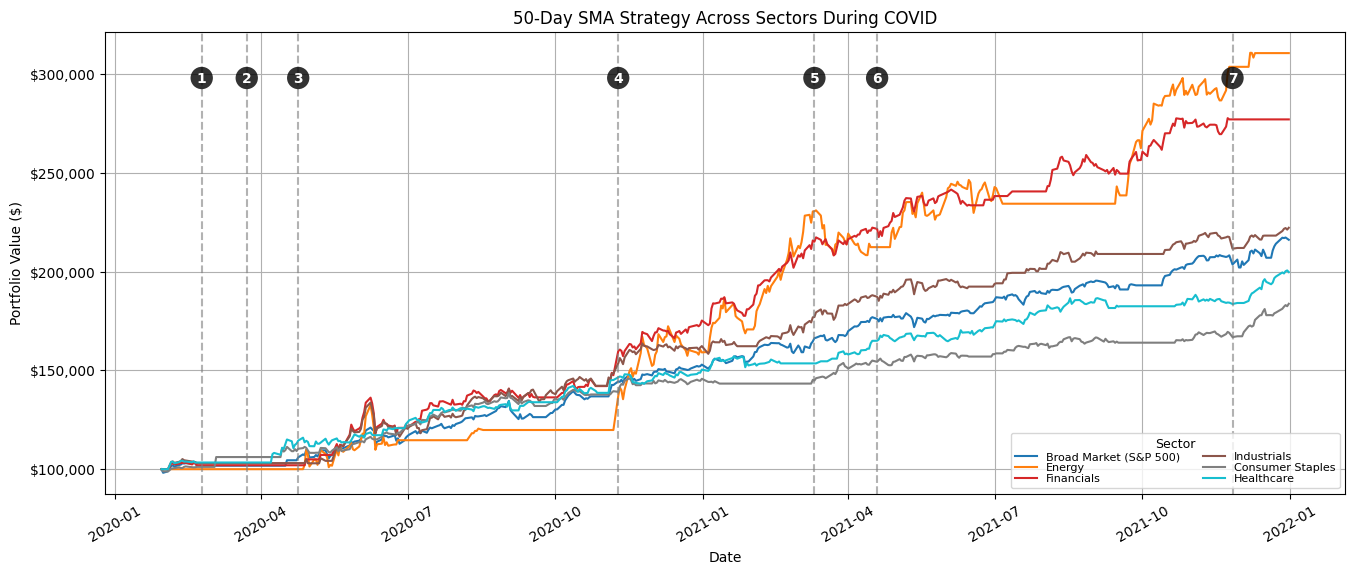


==================== MARKET TIMELINE ====================
1. February 24, 2020: Market Selloff Begins
2. March 23, 2020: Market hits its bottom for the year
3. April 24, 2020: First States Begin Limited Reopening
4. November 09, 2020: Pfizer Vaccine Announcement
5. March 11, 2020: The American Rescue Plan, a $1.9T stimulus package is signed into law
6. April 19, 2020: First U.S. Mass Vaccination Rollout
7. November 26, 2020: Increasing volatility driven by rising inflation and concerns over the Omicron variant


In [34]:
print_time_series(sma50_full_results, "50-Day SMA")

##5.3. Buy-the-Dip

Rules:

* Stay in cash if the last 5-day return is ≤ –5%.
* Stay invested otherwise.



In [35]:
btd_full_results = apply_strategy_to_period(buy_the_dip, PERIOD_START, PERIOD_END, initial_capital=100000)

In [36]:
print_results(MARKETS, btd_full_results, "Buy-the-Dip")


----- Buy-the-Dip -----

----- SPY (Broad Market (S&P 500)) -----
Initial Capital: $100,000.00
Final Portfolio Value: $234,103.44
Total Return: 134.10%

----- XLE (Energy) -----
Initial Capital: $100,000.00
Final Portfolio Value: $553,566.46
Total Return: 453.57%

----- XLF (Financials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $272,126.14
Total Return: 172.13%

----- XLI (Industrials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $205,650.20
Total Return: 105.65%

----- XLP (Consumer Staples) -----
Initial Capital: $100,000.00
Final Portfolio Value: $150,480.45
Total Return: 50.48%

----- XLV (Healthcare) -----
Initial Capital: $100,000.00
Final Portfolio Value: $189,499.89
Total Return: 89.50%


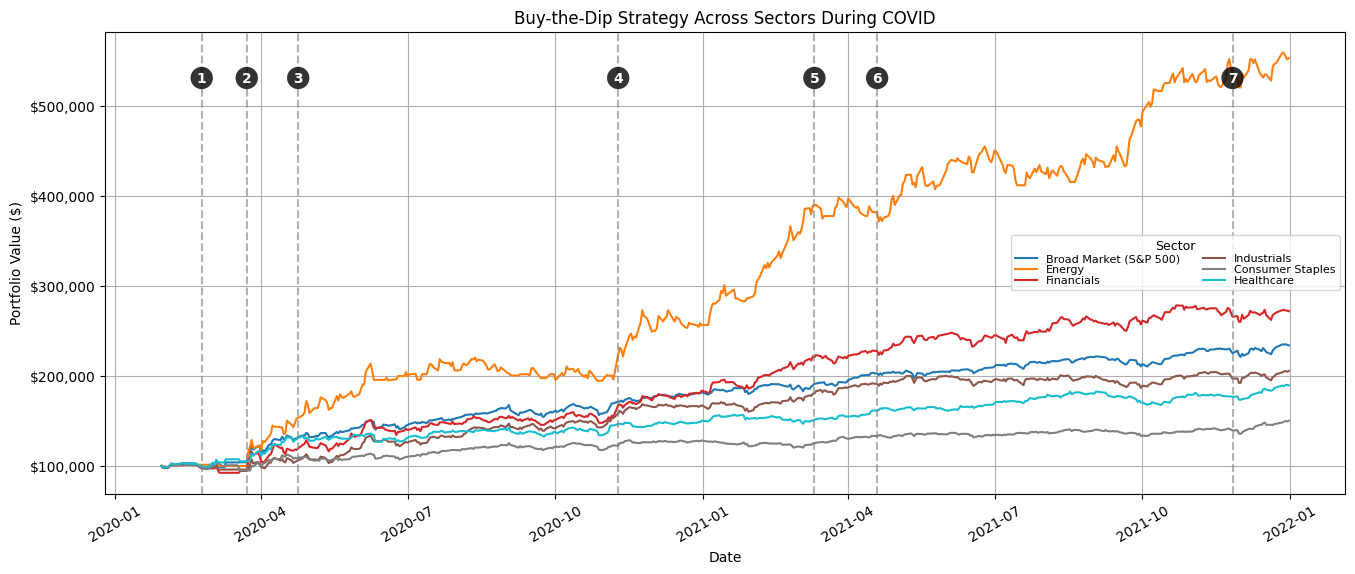


==================== MARKET TIMELINE ====================
1. February 24, 2020: Market Selloff Begins
2. March 23, 2020: Market hits its bottom for the year
3. April 24, 2020: First States Begin Limited Reopening
4. November 09, 2020: Pfizer Vaccine Announcement
5. March 11, 2020: The American Rescue Plan, a $1.9T stimulus package is signed into law
6. April 19, 2020: First U.S. Mass Vaccination Rollout
7. November 26, 2020: Increasing volatility driven by rising inflation and concerns over the Omicron variant


In [37]:
print_time_series(btd_full_results, "Buy-the-Dip")

##5.4. Multi-Factor Technical Strategy (Weighted Composite Score)


In [38]:
mf_full_results = apply_strategy_to_period(mf_signals, PERIOD_START, PERIOD_END, initial_capital=100000)

In [39]:
print_results(MARKETS, mf_full_results, "Multi-Factor Technical Strategy)")


----- Multi-Factor Technical Strategy) -----

----- SPY (Broad Market (S&P 500)) -----
Initial Capital: $100,000.00
Final Portfolio Value: $194,026.42
Total Return: 94.03%

----- XLE (Energy) -----
Initial Capital: $100,000.00
Final Portfolio Value: $534,958.75
Total Return: 434.96%

----- XLF (Financials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $338,300.92
Total Return: 238.30%

----- XLI (Industrials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $241,969.20
Total Return: 141.97%

----- XLP (Consumer Staples) -----
Initial Capital: $100,000.00
Final Portfolio Value: $187,821.83
Total Return: 87.82%

----- XLV (Healthcare) -----
Initial Capital: $100,000.00
Final Portfolio Value: $180,360.99
Total Return: 80.36%


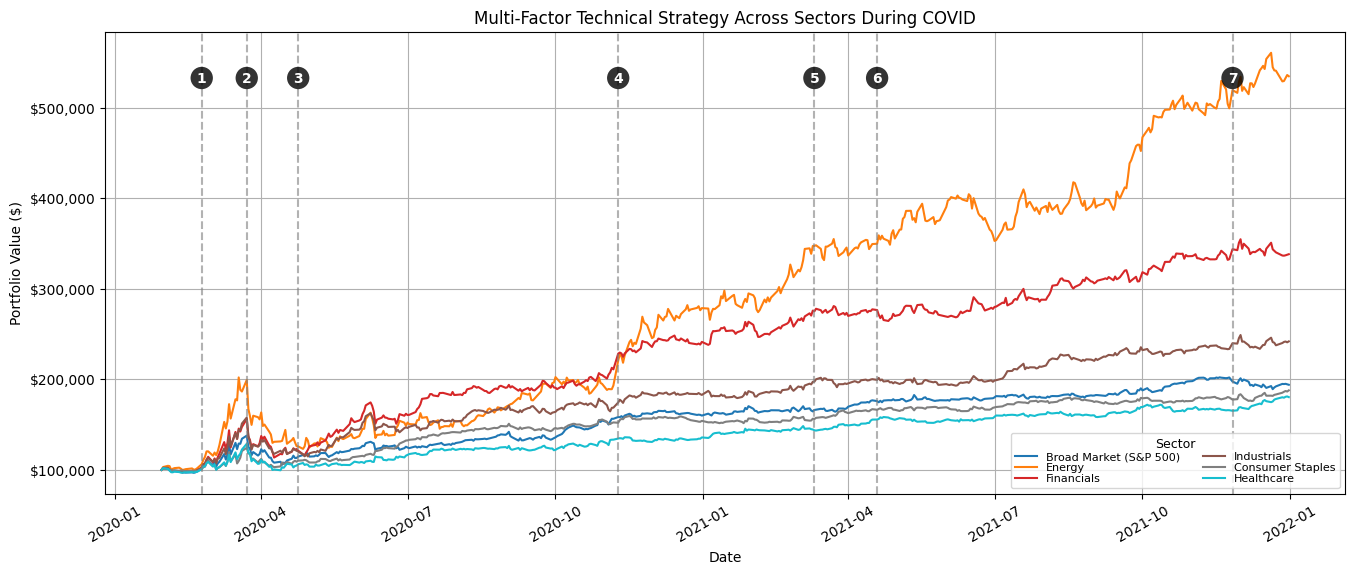


==================== MARKET TIMELINE ====================
1. February 24, 2020: Market Selloff Begins
2. March 23, 2020: Market hits its bottom for the year
3. April 24, 2020: First States Begin Limited Reopening
4. November 09, 2020: Pfizer Vaccine Announcement
5. March 11, 2020: The American Rescue Plan, a $1.9T stimulus package is signed into law
6. April 19, 2020: First U.S. Mass Vaccination Rollout
7. November 26, 2020: Increasing volatility driven by rising inflation and concerns over the Omicron variant


In [40]:
print_time_series(mf_full_results, "Multi-Factor Technical")

##5.5. Regime Strategy

Rules:

**Uptrend vs Downtrend**
*   Signal -> True when Close > 20-day moving average (SMA_20)
*   Signal -> False when Close ≤ SMA_20

**Normal vs Extreme Volatility**
*   volatility = rolling std of daily returns
*   Signal -> True when 20-Day volatility < 60-day average volatility
*   Signal -> False when 20-day volatility ≥ 60-day average volatility

**Normal vs Low Volume**
*   Signal -> True when current volume ≥ 80% of 20-day average volume
*   Signal -> False when current volume < 80% of 20-day average volume

**Panic Day Rule**
*   Sell (Signal=False) when daily return ≤ –4% &
*   Sell when Intraday Range ≥ 5% ((High–Low) / Close) &
*   Sell when daily volume is unusually high (1.5x) compared to the 20-day moving average.

**Gap Panic Rule**
*   Gap = (Today's Open – Yesterday's Close) /Yesterday's Close
*   Sell when Gap down ≤ –3% at the Open



In [41]:
regime_full_results = apply_strategy_to_period(regime_strategy, PERIOD_START, PERIOD_END, initial_capital=100000)

In [42]:
print_results(MARKETS, regime_full_results, "Regime Strategy")


----- Regime Strategy -----

----- SPY (Broad Market (S&P 500)) -----
Initial Capital: $100,000.00
Final Portfolio Value: $131,092.68
Total Return: 31.09%

----- XLE (Energy) -----
Initial Capital: $100,000.00
Final Portfolio Value: $259,391.23
Total Return: 159.39%

----- XLF (Financials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $178,757.05
Total Return: 78.76%

----- XLI (Industrials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $163,169.79
Total Return: 63.17%

----- XLP (Consumer Staples) -----
Initial Capital: $100,000.00
Final Portfolio Value: $135,528.67
Total Return: 35.53%

----- XLV (Healthcare) -----
Initial Capital: $100,000.00
Final Portfolio Value: $143,170.62
Total Return: 43.17%


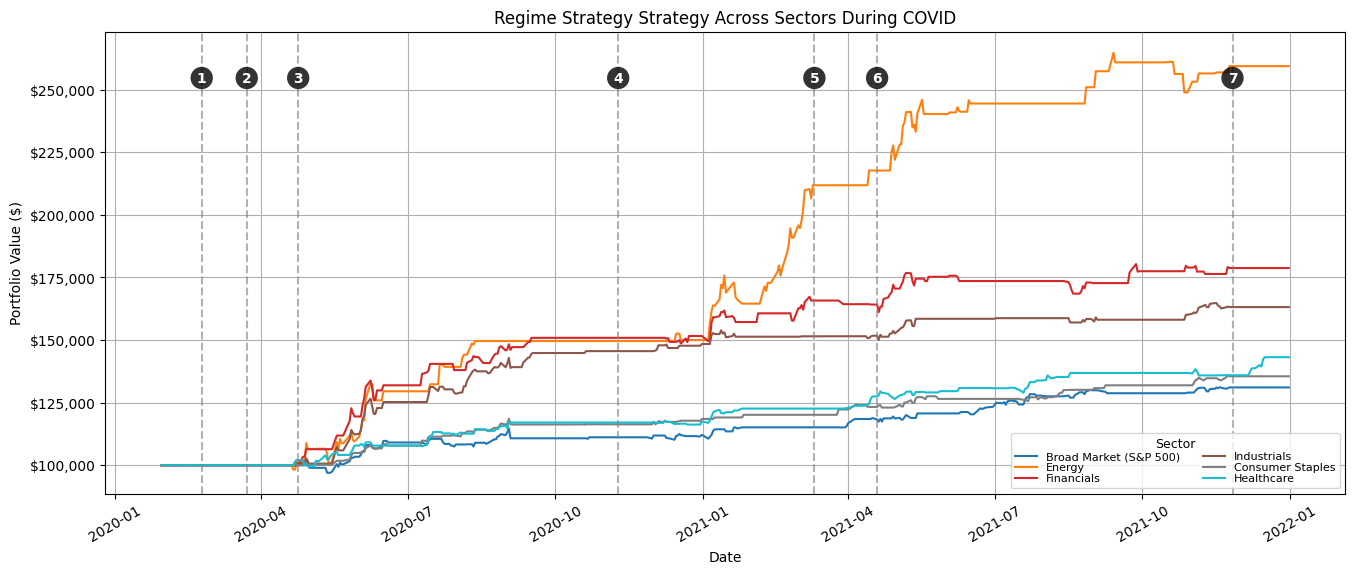


==================== MARKET TIMELINE ====================
1. February 24, 2020: Market Selloff Begins
2. March 23, 2020: Market hits its bottom for the year
3. April 24, 2020: First States Begin Limited Reopening
4. November 09, 2020: Pfizer Vaccine Announcement
5. March 11, 2020: The American Rescue Plan, a $1.9T stimulus package is signed into law
6. April 19, 2020: First U.S. Mass Vaccination Rollout
7. November 26, 2020: Increasing volatility driven by rising inflation and concerns over the Omicron variant


In [43]:
print_time_series(regime_full_results, "Regime Strategy")

##5.6. Simple Moving Average Crossover

In [44]:
smaC_full_results = apply_strategy_to_period(smaC_strategy, PERIOD_START, PERIOD_END, initial_capital=100000)

In [45]:
print_results(MARKETS, smaC_full_results, "SMA Crossover")


----- SMA Crossover -----

----- SPY (Broad Market (S&P 500)) -----
Initial Capital: $100,000.00
Final Portfolio Value: $124,833.88
Total Return: 24.83%

----- XLE (Energy) -----
Initial Capital: $100,000.00
Final Portfolio Value: $144,757.19
Total Return: 44.76%

----- XLF (Financials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $98,677.12
Total Return: -1.32%

----- XLI (Industrials) -----
Initial Capital: $100,000.00
Final Portfolio Value: $90,614.90
Total Return: -9.39%

----- XLP (Consumer Staples) -----
Initial Capital: $100,000.00
Final Portfolio Value: $111,815.09
Total Return: 11.82%

----- XLV (Healthcare) -----
Initial Capital: $100,000.00
Final Portfolio Value: $132,793.03
Total Return: 32.79%


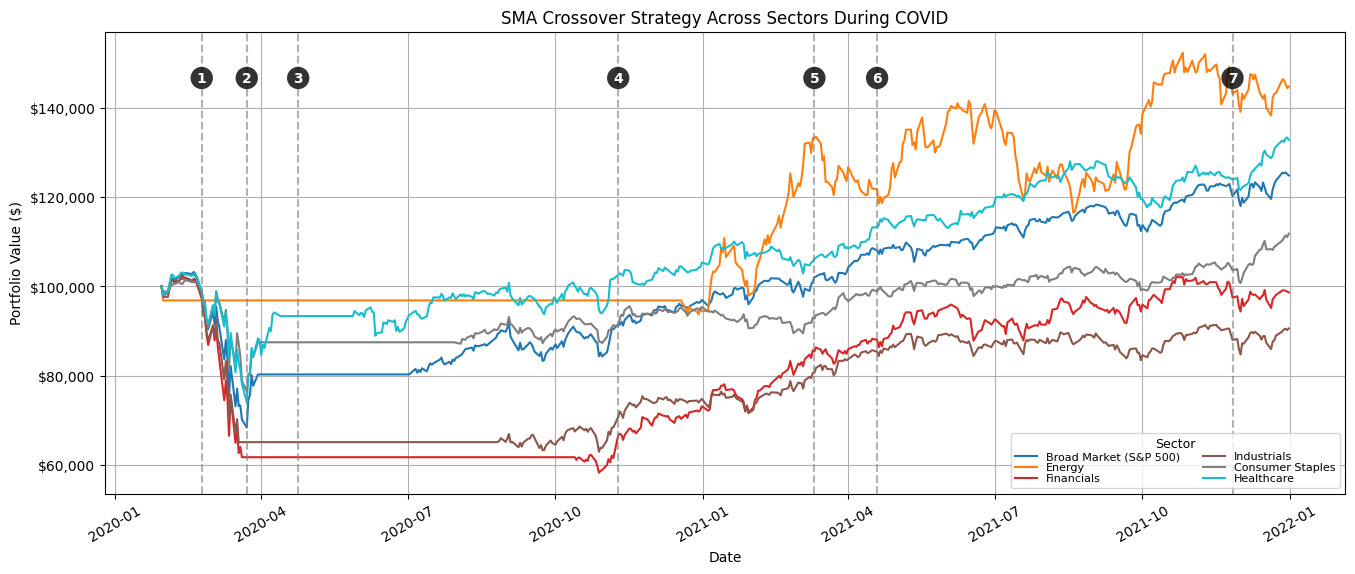


==================== MARKET TIMELINE ====================
1. February 24, 2020: Market Selloff Begins
2. March 23, 2020: Market hits its bottom for the year
3. April 24, 2020: First States Begin Limited Reopening
4. November 09, 2020: Pfizer Vaccine Announcement
5. March 11, 2020: The American Rescue Plan, a $1.9T stimulus package is signed into law
6. April 19, 2020: First U.S. Mass Vaccination Rollout
7. November 26, 2020: Increasing volatility driven by rising inflation and concerns over the Omicron variant


In [46]:
print_time_series(smaC_full_results, "SMA Crossover")

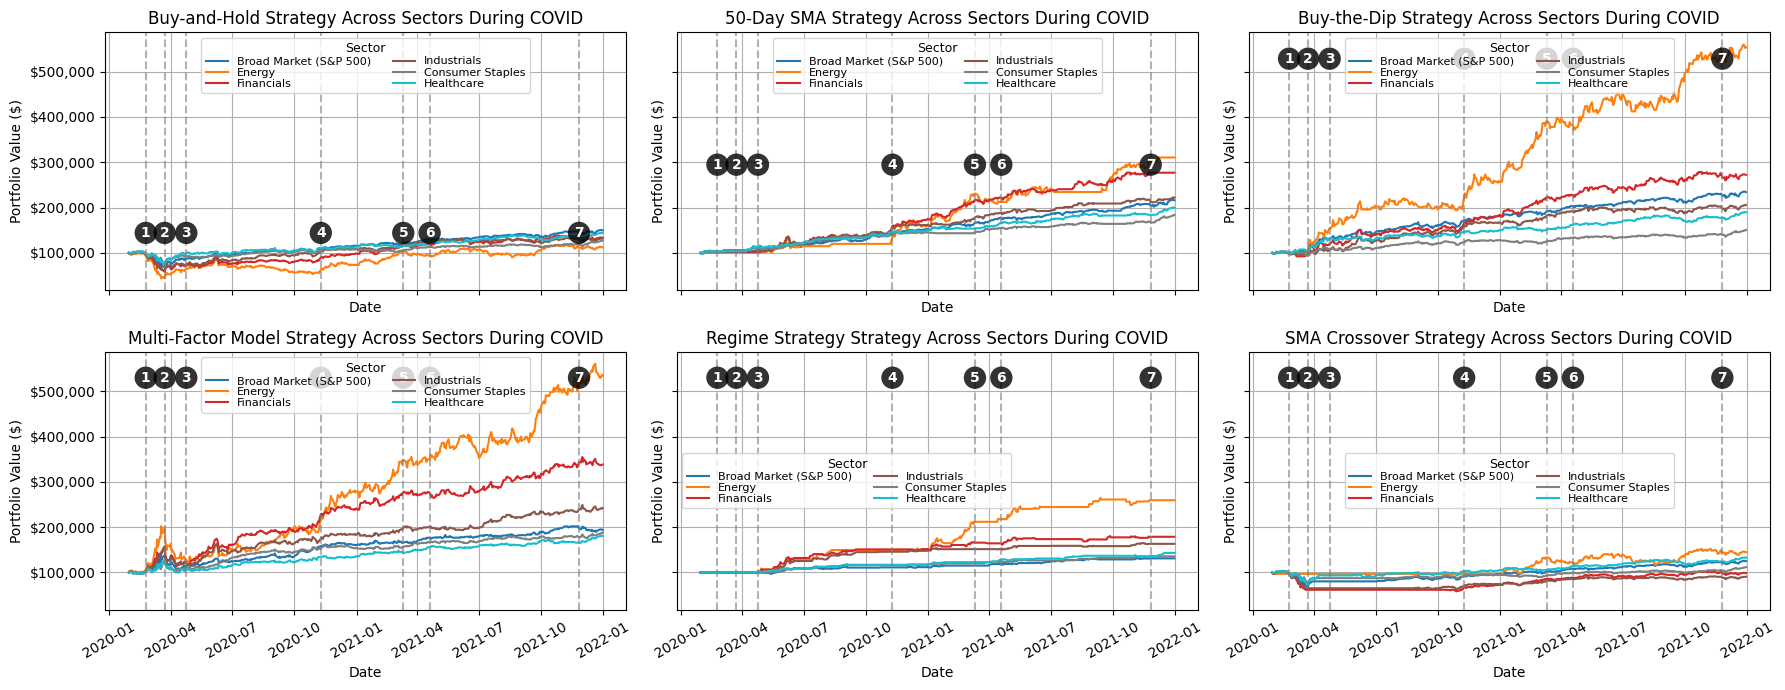

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.flatten()

print_time_series(bh_full_results, "Buy-and-Hold", ax=axes[0])
print_time_series(sma50_full_results, "50-Day SMA", ax=axes[1])
print_time_series(btd_full_results, "Buy-the-Dip", ax=axes[2])
print_time_series(mf_full_results, "Multi-Factor Model", ax=axes[3])
print_time_series(regime_full_results, "Regime Strategy", ax=axes[4])
print_time_series(smaC_full_results, "SMA Crossover", ax=axes[5])

plt.tight_layout()
plt.show()

#6. Strategy Resilience Under Market Stress

In [48]:
full_returns_df = returns_for_period(PERIOD_START, PERIOD_END, initial_capital=100000)
full_returns_df.head(6)

,Broad Market (S&P 500),Energy,Financials,Industrials,Consumer Staples,Healthcare
Buy & Hold,49.621293,12.331488,33.236440,31.762993,27.197810,43.783787
50-Day SMA,116.042719,210.474597,176.941691,122.130683,83.676974,99.695021
Buy-the-Dip,134.103445,453.566465,172.126137,105.650199,50.480455,89.499893
Multi-Factor Technical,94.026424,434.958754,238.300922,141.969200,87.821831,80.360993
Regime Strategy,31.092684,159.391228,78.757050,63.169791,35.528669,43.170616
SMA Crossover,24.833876,44.757194,-1.322883,-9.385101,11.815090,32.793028


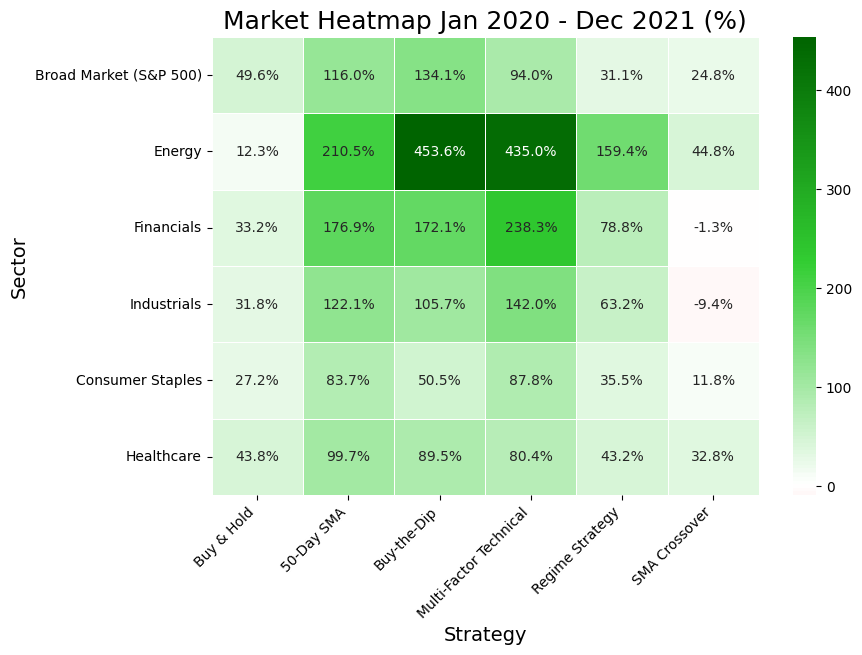

In [49]:
print_heatmap(full_returns_df, PERIOD_START, PERIOD_END)
fig = plt.gcf()
fig.set_size_inches(8, 7)

In [50]:
crash_returns_df = returns_for_period(CRASH_START, RECOVERY_END, initial_capital=100000)
crash_returns_df.head(6)

,Broad Market (S&P 500),Energy,Financials,Industrials,Consumer Staples,Healthcare
Buy & Hold,9.343363,-22.563954,-5.866157,8.439279,5.798843,6.673356
50-Day SMA,43.839136,66.958308,64.526384,57.913775,42.061752,39.060456
Buy-the-Dip,71.082988,166.596532,75.052028,66.896180,25.164561,40.590187
Multi-Factor Technical,44.769893,120.958088,132.464212,81.326321,44.903664,19.227873
Regime Strategy,11.174395,49.615081,50.891732,45.581577,16.357316,17.065456
SMA Crossover,-8.771302,0.000000,-30.282915,-25.425082,-6.995984,-1.480701


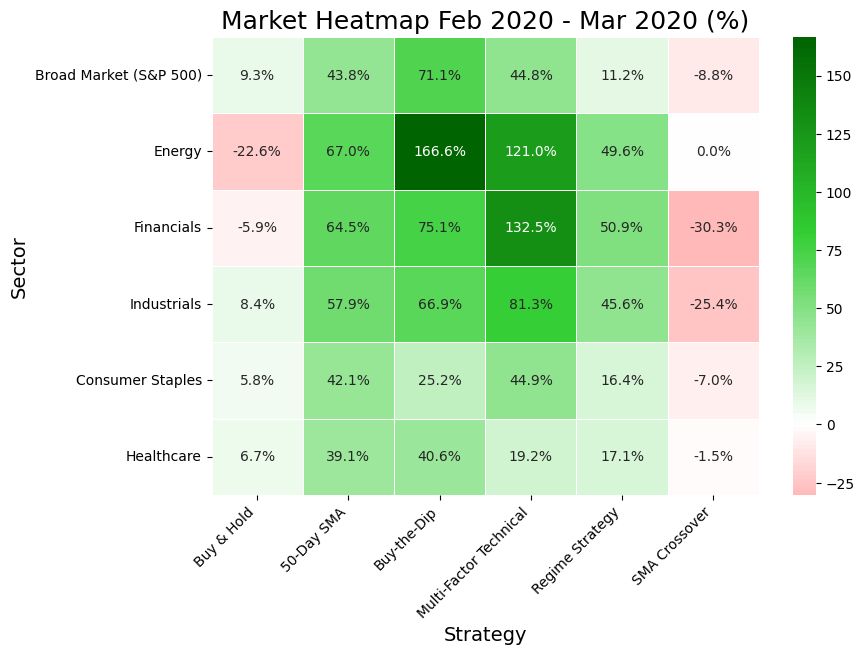

In [51]:
print_heatmap(crash_returns_df, CRASH_START, CRASH_END)
fig = plt.gcf()
fig.set_size_inches(8, 7)

#7. Strategy Behavior During Recovery and Regime Shifts

In [52]:
recovery_returns_df = returns_for_period(RECOVERY_START, RECOVERY_END, 100000)
recovery_returns_df.head(6)

,Broad Market (S&P 500),Energy,Financials,Industrials,Consumer Staples,Healthcare
Buy & Hold,50.639025,51.731617,46.103094,64.539506,32.838481,36.538110
50-Day SMA,45.335886,66.958308,66.130462,58.707261,35.179940,38.979837
Buy-the-Dip,54.915842,135.761914,67.462833,75.867694,33.203364,36.509922
Multi-Factor Technical,0.157376,18.944042,23.497399,-2.059108,14.619721,-6.544909
Regime Strategy,11.174395,49.615081,50.891732,45.581577,16.357316,17.065456
SMA Crossover,25.683003,0.000000,14.548357,15.783406,16.773604,26.101207


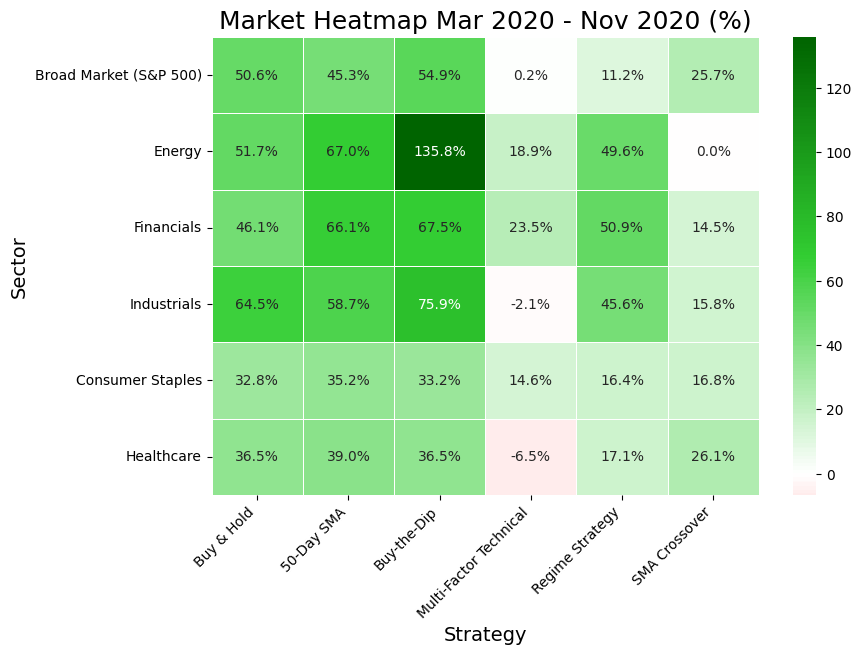

In [53]:
print_heatmap(recovery_returns_df, RECOVERY_START, RECOVERY_END)
fig = plt.gcf()
fig.set_size_inches(8, 7)